Свёрточные нейронные сети для визуального распознавания

>**k-Nearest Neighbor (kNN)** - классификация на основе поиска ближайших соседей.  

Классификатор kNN состоит из двух этапов:

- Во время обучения классификатор берет обучающие данные и просто запоминает их.
- Во время тестирования kNN классифицирует каждое тестовое изображение, сравнивая его со всеми обучающими изображениями и перенося метки k наиболее похожих обучающих примеров.
- Значение k проверяется с помощью перекрестной проверки.

В этом упражнении вы реализуете эти шаги и поймете базовый конвейер классификации изображений, перекрестную проверку, а также приобретете навыки написания эффективного векторизованного кода.

In [5]:
%load_ext autoreload
%autoreload 2

import gc
import logging
import matplotlib.pyplot as plt

# Настраиваем формат вывода логов (базовая настройка)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Настраиваем глобальные параметры библиотеки matplotlib
plt.rcParams['figure.figsize'] = (10.0, 8.0) # размер в дюймах по умолчанию (1000х800 px)
plt.rcParams['image.interpolation'] = 'nearest' # отключаем сглаживание, мыло
plt.rcParams['image.cmap'] = 'gray' # для отображения одноканальынх изображений

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


1. Заменил try/except на globals и gc.collect()
> + Предсказуемость памяти, + Безопасность (нет bare except), + Чистота кода

2. Добавил assert (для отладки и разработки), проверка датасета перед обработкой  
Но при запуске скрипта с флагом оптимизации, assert игнориуется, поэтому заменим на if ... raise

3. Подключил psutil, создал log_memory_usage для проверки памяти

4. Заменил небезопасные сравнения shape на проверку конкретно нулевой размерности (shape[0]).

---

## Датасет CIFAR-10
Сбалансированный датасет — это выборка, в которой каждого класса объектов присутствует одинаковое количество (или почти одинаковое).

- В **CIFAR-10** ровно 50 000 картинок и 10 классов. Каждому классу (кошкам, машинам, самолетам) принадлежит ровно по 5 000 картинок. Датасет идеально сбалансирован.  

- Если бы у вас было 45 000 картинок собак и всего 500 картинок кошек, такой датасет назывался бы **несбалансированным** (imbalanced). Обучать модели на несбалансированных данных опасно: ИИ станет «ленивым», начнет везде угадывать только собак и получать высокую точность, полностью игнорируя редких кошек.

In [8]:
from data_utils import load_and_validate_cifar10

cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Очистка памяти предыдущего запуска ячейки
if 'X_train' in globals():
   del X_train, y_train, X_test, y_test
   gc.collect()

X_train, y_train, X_test, y_test = load_and_validate_cifar10(cifar10_dir)

logging.info(f"X_train: {X_train.shape}")
logging.info(f"y_train метки (0-9): {y_train.shape}")
logging.info(f"X_test: {X_test.shape}")
logging.info(f"y_test: {y_test.shape}")

2026-08-06 20:00:35,061 - INFO - Starting CIFAR-10 loading pipeline, Current RAM: 117.82 MB
2026-08-06 20:00:35,550 - INFO - Data loaded into RAM. Current RAM: 1524.09 MB
2026-08-06 20:00:35,551 - INFO - Data validation successful. Shapes: Train (50000, 32, 32, 3), Test (10000, 32, 32, 3)
2026-08-06 20:00:35,551 - INFO - X_train: (50000, 32, 32, 3)
2026-08-06 20:00:35,551 - INFO - y_train метки (0-9): (50000,)
2026-08-06 20:00:35,552 - INFO - X_test: (10000, 32, 32, 3)
2026-08-06 20:00:35,552 - INFO - y_test: (10000,)



---

#### Оптимизация если будет 5000000 картинок и меток:  

Способ 1. Использование встроенных итераторов (Lazy Evaluation)  

- Например, в PyTorch вы просто создаете DataLoader со случайным сэмплером, и он сам достает вам нужные 7 штук, не сканируя весь датасет целиком:


In [ ]:
train_loader = DataLoader(dataset, batch_size=7, shuffle=True)  
images, labels = next(iter(train_loader))


Способ 2. Предварительная индексация (Группировка)  

Если вам нужно часто визуализировать или сэмплировать данные из 5-миллионного датасета, операцию поиска индексов делают всего один раз при загрузке данных, создавая поисковый индекс (инвертированный индекс):

In [ ]:
from collections import defaultdict

# 1. Один раз пробегаем по датасету и раскладываем индексы по полочкам
# Это занимает время, но делается ЕДИНОЖДЫ
class_to_idxs = defaultdict(list)
for idx, label in enumerate(y_train):
    class_to_idxs[label].append(idx)

# 2. Теперь выборка 7 картинок для любого класса происходит МГНОВЕННО:
# Мы не сканируем 5 000 000 строк, а сразу берем готовый список нужного класса
idxs = np.random.choice(class_to_idxs[target_class], 7, replace=False)


Способ 3. Случайный поиск до первого попадания (Reservoir Sampling)  

Если память жестко ограничена, используют алгоритмы вероятностного сэмплинга. Компьютер просто генерирует случайный индекс от 0 до 5 000 000, смотрит на класс картинки, и если он совпал с нужным — забирает её в корзину. Как только в корзине набралось 7 штук — алгоритм останавливается. На огромных данных это работает быстрее, чем сканирование всего массива.

---

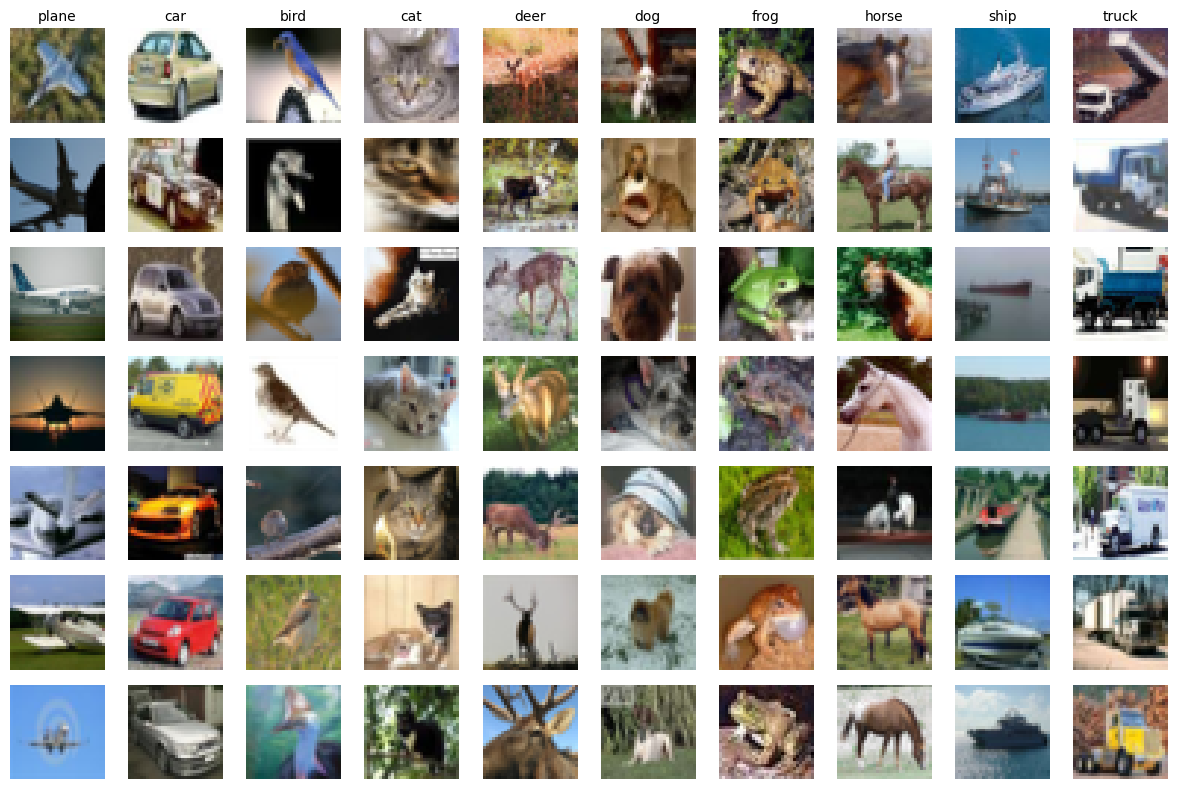

In [14]:
import numpy as np
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7

# Используем современный RNG для воспроизводимости
rng = np.random.default_rng(seed=42)

# Создаем сразу всю сетку осей (Axes) и задаем размер фигуры
fig, axes = plt.subplots(
    nrows=samples_per_class, 
    ncols=num_classes, 
    figsize=(12, 8)
)

for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    selected_idxs = rng.choice(idxs, size=samples_per_class, replace=False)

    for i, idx in enumerate(selected_idxs):
        ax = axes[i, y]
        ax.imshow(X_train[idx].astype('uint8'))
        ax.axis('off')
        if i == 0:
            ax.set_title(cls, fontsize=10)

plt.tight_layout()
plt.show()

#### Как NumPy управляет памятью

1. Basic Indexing (Срезы / Slices)

Когда вы используете двоеточие, например: `X_train[:5000]`.

- **Как это работает:** NumPy **не копирует** данные. Он создает так называемое **представление (View)**.
- **Что происходит в памяти:** Новый массив просто ссылается на тот же самый кусок памяти, где лежат исходные 50 000 картинок, но указывает процессору: _«читай только от 0 до 5000»_.   
 $O(1)$

2. Advanced / Fancy Indexing (Маски и списки)

Это как раз ваш случай: `X_train[mask]`, где `mask` — это список или массив индексов.

- **Как это работает:** NumPy **обязан сделать полную физическую копию** данных в памяти.
- **Почему так происходит:** Элементы в списке `mask` не обязательно должны идти по порядку. Вы могли бы написать `mask = [10, 0, 500, 3]`. Так как данные в памяти компьютера должны лежать строго последовательно («куском»), NumPy физически не может сделать View для разрозненных индексов. Ему приходится выделить в оперативной памяти **новый чистый буфер** и скопировать туда пиксели выбранных картинок один за другим.

Но представьте реальный проект с терабайтным датасетом:

- Если вы напишете `X_large[mask]`, ваш сервер попытается скопировать сотни гигабайт данных в новый буфер.
- Программа мгновенно упадет из-за нехватки RAM.

Урезает с 50000 до 5000 для KNN для скорости:

In [ ]:
num_training = 5000
X_train = X_train[:num_training]
y_train = y_train[:num_training]

num_test = 500
X_test = X_test[:num_test]
y_test = y_test[:num_test]

(5000, 3072) (500, 3072)


#### Сплющивание тензоров (Reshaping)

Исходная форма тензора X_train — (5000, 32, 32, 3) (5000 картинок размером $32 \times 32$ пикселя и 3 цветовых канала RGB).

- **np.reshape(array, newshape)**: Изменяет геометрию массива без изменения его содержимого в памяти.
    
- **Первый аргумент X_train.shape[0]**: Сохраняет размерность по оси 0 (количество объектов $N = 5000$).
    
- **Магия -1**: «вычисляет размерность автоматически на основе общего количества элементов в массиве».
    
    - Общее число элементов картинки: $32 \times 32 \times 3 = 3072$.
        
    - NumPy делит общее количество элементов в массиве на X_train.shape[0] и автоматически подставляет 3072.
        
- **Результат**: Изображение из 3D-тензора $(32, 32, 3)$ превращается в один плоский вектор-строку длины $3072$.
    
    - Весь массив X_train стал обычной двухмерной матрицей (таблицей) (5000, 3072).
    - Аналогично X_test

Если завтра разрешение картинок изменится (например, станет 64x64), код с -1 не придется переписывать — он посчитает всё сам.

Зачем мы это сделали?Теперь у нас есть две простые таблицы. И чтобы алгоритм k-NN мог сравнить тестовую картинку с тренировочной, ему достаточно будет взять строку №0 из первой таблицы, строку №0 из второй таблицы и посчитать расстояние между этими двумя длинными векторами.


In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
print(X_train.shape, X_test.shape)

In [ ]:
from cs231n.classifiers import KNearestNeighbor

# Create a kNN classifier instance.
# Remember that training a kNN classifier is a noop:
# the Classifier simply remembers the data and does no further processing
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

We would now like to classify the test data with the kNN classifier. Recall that we can break down this process into two steps:

1. First we must compute the distances between all test examples and all train examples.
2. Given these distances, for each test example we find the k nearest examples and have them vote for the label

Lets begin with computing the distance matrix between all training and test examples. For example, if there are **Ntr** training examples and **Nte** test examples, this stage should result in a **Nte x Ntr** matrix where each element (i,j) is the distance between the i-th test and j-th train example.

**Note: For the three distance computations that we require you to implement in this notebook, you may not use the np.linalg.norm() function that numpy provides.**

First, open `cs231n/classifiers/k_nearest_neighbor.py` and implement the function `compute_distances_two_loops` that uses a (very inefficient) double loop over all pairs of (test, train) examples and computes the distance matrix one element at a time.

In [ ]:
# Open cs231n/classifiers/k_nearest_neighbor.py and implement
# compute_distances_two_loops.

# Test your implementation:
dists = classifier.compute_distances_two_loops(X_test)
print(dists.shape)

In [ ]:
# We can visualize the distance matrix: each row is a single test example and
# its distances to training examples
plt.imshow(dists, interpolation='none')
plt.show()

**Inline Question 1**

Notice the structured patterns in the distance matrix, where some rows or columns are visibly brighter. (Note that with the default color scheme black indicates low distances while white indicates high distances.)

- What in the data is the cause behind the distinctly bright rows?
- What causes the columns?

$\color{blue}{\textit Your Answer:}$ *fill this in.*



In [ ]:
# Now implement the function predict_labels and run the code below:
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

You should expect to see approximately `27%` accuracy. Now lets try out a larger `k`, say `k = 5`:

In [ ]:
y_test_pred = classifier.predict_labels(dists, k=5)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

You should expect to see a slightly better performance than with `k = 1`.

**Inline Question 2**

We can also use other distance metrics such as L1 distance.
For pixel values $p_{ij}^{(k)}$ at location $(i,j)$ of some image $I_k$,

the mean $\mu$ across all pixels over all images is $$\mu=\frac{1}{nhw}\sum_{k=1}^n\sum_{i=1}^{h}\sum_{j=1}^{w}p_{ij}^{(k)}$$
And the pixel-wise mean $\mu_{ij}$ across all images is
$$\mu_{ij}=\frac{1}{n}\sum_{k=1}^np_{ij}^{(k)}.$$
The general standard deviation $\sigma$ and pixel-wise standard deviation $\sigma_{ij}$ is defined similarly.

Which of the following preprocessing steps will not change the performance of a Nearest Neighbor classifier that uses L1 distance? Select all that apply. To clarify, both training and test examples are preprocessed in the same way.

1. Subtracting the mean $\mu$ ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu$.)
2. Subtracting the per pixel mean $\mu_{ij}$  ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu_{ij}$.)
3. Subtracting the mean $\mu$ and dividing by the standard deviation $\sigma$.
4. Subtracting the pixel-wise mean $\mu_{ij}$ and dividing by the pixel-wise standard deviation $\sigma_{ij}$.
5. Rotating the coordinate axes of the data, which means rotating all the images by the same angle. Empty regions in the image caused by rotation are padded with a same pixel value and no interpolation is performed.

$\color{blue}{\textit Your Answer:}$


$\color{blue}{\textit Your Explanation:}$


In [ ]:
# Now lets speed up distance matrix computation by using partial vectorization
# with one loop. Implement the function compute_distances_one_loop and run the
# code below:
dists_one = classifier.compute_distances_one_loop(X_test)

# To ensure that our vectorized implementation is correct, we make sure that it
# agrees with the naive implementation. There are many ways to decide whether
# two matrices are similar; one of the simplest is the Frobenius norm. In case
# you haven't seen it before, the Frobenius norm of two matrices is the square
# root of the squared sum of differences of all elements; in other words, reshape
# the matrices into vectors and compute the Euclidean distance between them.
difference = np.linalg.norm(dists - dists_one, ord='fro')
print('One loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

In [ ]:
# Now implement the fully vectorized version inside compute_distances_no_loops
# and run the code
dists_two = classifier.compute_distances_no_loops(X_test)

# check that the distance matrix agrees with the one we computed before:
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('No loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

In [ ]:
# Let's compare how fast the implementations are
def time_function(f, *args):
    """
    Call a function f with args and return the time (in seconds) that it took to execute.
    """
    import time
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('Two loop version took %f seconds' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('One loop version took %f seconds' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('No loop version took %f seconds' % no_loop_time)

# You should see significantly faster performance with the fully vectorized implementation!

# NOTE: depending on what machine you're using,
# you might not see a speedup when you go from two loops to one loop,
# and might even see a slow-down.

### Cross-validation

We have implemented the k-Nearest Neighbor classifier but we set the value k = 5 arbitrarily. We will now determine the best value of this hyperparameter with cross-validation.

In [ ]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = []
y_train_folds = []
################################################################################
# TODO:                                                                        #
# Split up the training data into folds. After splitting, X_train_folds and    #
# y_train_folds should each be lists of length num_folds, where                #
# y_train_folds[i] is the label vector for the points in X_train_folds[i].     #
# Hint: Look up the numpy array_split function.                                #
################################################################################


# A dictionary holding the accuracies for different values of k that we find
# when running cross-validation. After running cross-validation,
# k_to_accuracies[k] should be a list of length num_folds giving the different
# accuracy values that we found when using that value of k.
k_to_accuracies = {}


################################################################################
# TODO:                                                                        #
# Perform k-fold cross validation to find the best value of k. For each        #
# possible value of k, run the k-nearest-neighbor algorithm num_folds times,   #
# where in each case you use all but one of the folds as training data and the #
# last fold as a validation set. Store the accuracies for all fold and all     #
# values of k in the k_to_accuracies dictionary.                               #
################################################################################


# Print out the computed accuracies
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

In [ ]:
# plot the raw observations
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('Cross-validation on k')
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.show()

In [ ]:
# Based on the cross-validation results above, choose the best value for k,
# retrain the classifier using all the training data, and test it on the test
# data. You should be able to get above 28% accuracy on the test data.
best_k = 1

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

**Inline Question 3**

Which of the following statements about $k$-Nearest Neighbor ($k$-NN) are true in a classification setting, and for all $k$? Select all that apply.
1. The decision boundary of the k-NN classifier is linear.
2. The training error of a 1-NN will always be lower than or equal to that of 5-NN.
3. The test error of a 1-NN will always be lower than that of a 5-NN.
4. The time needed to classify a test example with the k-NN classifier grows with the size of the training set.
5. None of the above.

$\color{blue}{\textit Your Answer:}$


$\color{blue}{\textit Your Explanation:}$

